# Tamanduateí Network Analysis
Road network vulnerability in the Tamanduateí basin

Pedro Borges — pedro.borges@inpe.br

In [ ]:
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

BASEMAP = ctx.providers.CartoDB.DarkMatter


def load_edges(path: Path) -> gpd.GeoDataFrame:
    """Load edges GeoPackage in EPSG:4326."""
    gdf = gpd.read_file(path)
    if gdf.crs and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)
    return gdf


def load_nodes(path: Path) -> gpd.GeoDataFrame:
    """Load nodes GeoPackage in EPSG:4326."""
    gdf = gpd.read_file(path)
    if gdf.crs and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)
    return gdf


def load_station(path: Path, station_id: int) -> gpd.GeoDataFrame:
    """Load a single station from the stations GeoJSON."""
    gdf = gpd.read_file(path)
    station = gdf[gdf["posto"] == station_id].copy()
    if station.crs and station.crs.to_epsg() != 4326:
        station = station.to_crs(epsg=4326)
    return station


def _get_normalization_bounds(
    gdf: gpd.GeoDataFrame, column: str
) -> tuple[float, float]:
    """Get normalization bounds for a variable."""
    values = gdf[column]
    if column == "k_i":
        return 1.0, 10.0
    elif column == "c_i":
        return 0.0, 1.0
    elif column in ("b_i", "avg_l_i"):
        return float(values.min()), float(np.percentile(values.dropna(), 99))
    elif column in ("v_i", "v_ij"):
        return 0.0, float(values.max()) if values.max() > 0 else 1.0
    elif column == "e_ij":
        return float(values.min()), float(np.percentile(values.dropna(), 99))
    else:
        return float(values.min()), float(values.max())


def _plot_station(ax: plt.Axes, station_gdf: gpd.GeoDataFrame) -> None:
    """Overlay station point on a map axis."""
    for _, row in station_gdf.iterrows():
        ax.plot(
            row.geometry.x, row.geometry.y,
            marker="^", color="red", markersize=10,
            markeredgecolor="white", markeredgewidth=0.8,
            zorder=5, label=f"Estação {row['posto']}"
        )
    ax.legend(loc="lower right", fontsize=9)


def create_node_map(
    gdf: gpd.GeoDataFrame,
    column: str,
    label: str,
    log_scale: bool = False,
    station_gdf: gpd.GeoDataFrame | None = None,
) -> None:
    """Create a matplotlib map for a given node parameter."""
    vmin, vmax = _get_normalization_bounds(gdf, column)
    fig, ax = plt.subplots(figsize=(13, 8))

    plot_kwargs = dict(
        column=column,
        cmap="plasma",
        ax=ax,
        markersize=2,
        legend=True,
        legend_kwds={"label": label, "shrink": 0.6},
    )

    if log_scale:
        positive = gdf[column][gdf[column] > 0]
        log_vmin = float(positive.min()) if len(positive) > 0 else 1e-10
        plot_kwargs["norm"] = LogNorm(vmin=log_vmin, vmax=vmax)
    else:
        plot_kwargs["vmin"] = vmin
        plot_kwargs["vmax"] = vmax

    gdf.plot(**plot_kwargs)

    if station_gdf is not None:
        _plot_station(ax, station_gdf)

    ctx.add_basemap(ax, crs=gdf.crs, source=BASEMAP)
    ax.grid(True, alpha=0.2, linestyle="-")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def create_edge_map(
    gdf: gpd.GeoDataFrame,
    column: str,
    label: str,
    log_scale: bool = False,
    station_gdf: gpd.GeoDataFrame | None = None,
) -> None:
    """Create a matplotlib map for a given edge parameter."""
    vmin, vmax = _get_normalization_bounds(gdf, column)
    fig, ax = plt.subplots(figsize=(13, 8))

    plot_kwargs = dict(
        column=column,
        cmap="plasma",
        ax=ax,
        linewidth=0.5,
        legend=True,
        legend_kwds={"label": label, "shrink": 0.6},
    )

    if log_scale:
        positive = gdf[column][gdf[column] > 0]
        log_vmin = float(positive.min()) if len(positive) > 0 else 1e-10
        plot_kwargs["norm"] = LogNorm(vmin=log_vmin, vmax=vmax)
    else:
        plot_kwargs["vmin"] = vmin
        plot_kwargs["vmax"] = vmax

    gdf.plot(**plot_kwargs)

    if station_gdf is not None:
        _plot_station(ax, station_gdf)

    ctx.add_basemap(ax, crs=gdf.crs, source=BASEMAP)
    ax.grid(True, alpha=0.2, linestyle="-")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def parse_results(path: Path) -> dict[str, dict[str, str]]:
    """Parse results.txt into a dict of sections mapping parameter names to values."""
    sections = {}
    current_section = None
    text = path.read_text()
    for line in text.splitlines():
        line = line.strip()
        if not line or set(line) <= {"=", "-"}:
            continue
        if line.endswith(":"):
            current_section = line.rstrip(":")
            sections[current_section] = {}
        elif ":" in line:
            if current_section is None:
                current_section = "Global Network Parameters"
                sections[current_section] = {}
            key, value = line.split(":", 1)
            sections[current_section][key.strip()] = value.strip()
    return sections

In [ ]:
nodes_gdf = load_nodes(Path("data/output/nodes.gpkg"))
edges_gdf = load_edges(Path("data/output/edges.gpkg"))
results = parse_results(Path("data/output/results.txt"))
station_413 = load_station(Path("data/raw/stations.geojson"), 413)

## Global Network Parameters

In [3]:
section = results["Global Network Parameters"]
df = pd.DataFrame(
    [(k, v) for k, v in section.items()],
    columns=["Parameter", "Value"],
)
df.style.hide(axis="index")

Parameter,Value
Number of nodes (N),54557
Number of edges (L),130493


## Average Parameters

In [ ]:
section = results["Average Parameters"]
df = pd.DataFrame(
    [(k, v) for k, v in section.items()],
    columns=["Parameter", "Value"],
)
df.style.hide(axis="index")

## Average Shortest Path Lengths

In [ ]:
section = results["Average Shortest Path Lengths"]
df = pd.DataFrame(
    [(k, v) for k, v in section.items()],
    columns=["Metric", "Value"],
)
df.style.hide(axis="index")

## Maximum Parameters

In [ ]:
section = results["Maximum Parameters"]
df = pd.DataFrame(
    [(k, v) for k, v in section.items()],
    columns=["Parameter", "Value"],
)
df.style.hide(axis="index")

## Random Graph Comparison $G(N, p)$

In [ ]:
section = results["Theoretical Random Graph G(N, p)"]
df = pd.DataFrame(
    [(k, v) for k, v in section.items()],
    columns=["Parameter", "Value"],
)
df.style.hide(axis="index")

## Node Degree ($k_i$)

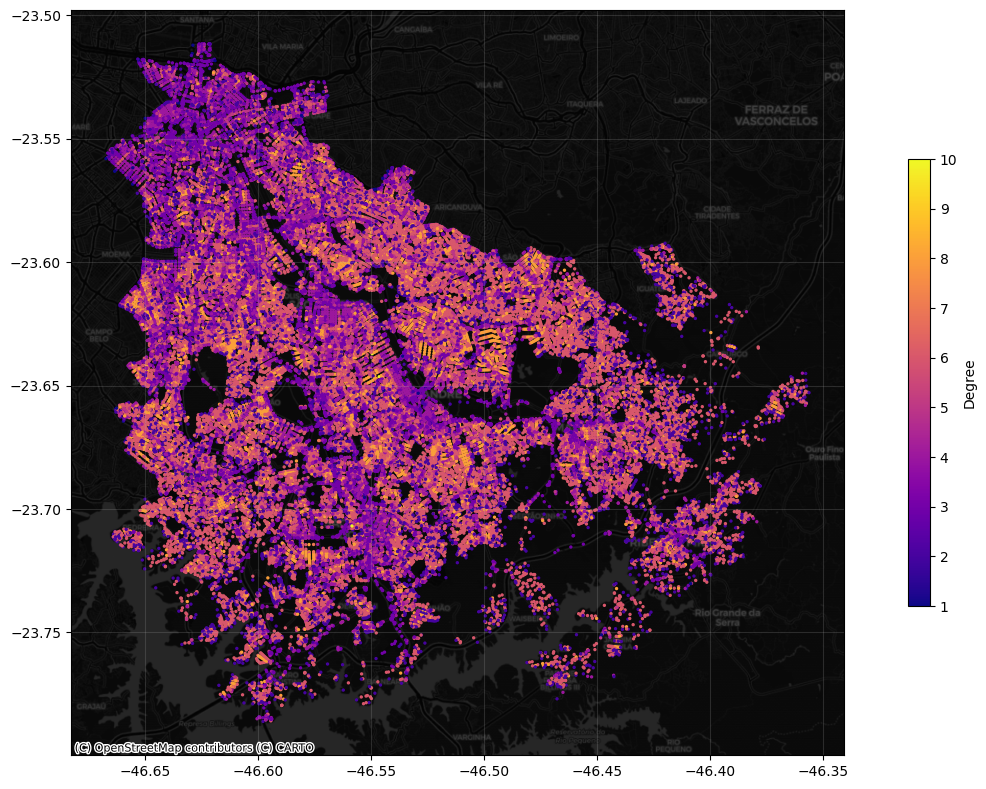

In [10]:
create_node_map(nodes_gdf, "k_i", "Degree")

## Clustering Coefficient ($c_i$)

In [ ]:
create_node_map(nodes_gdf, "c_i", "Clustering Coefficient")

## Betweenness Centrality ($b_i$)

In [ ]:
create_node_map(nodes_gdf, "b_i", "Betweenness Centrality")

## Average Edge Length ($\langle l_i \rangle$)

In [ ]:
create_node_map(nodes_gdf, "avg_l_i", "Avg Edge Length")

## Node Vulnerability ($v_i$)

In [ ]:
v_i_gdf = nodes_gdf[nodes_gdf["v_i"] > 0].copy()
create_node_map(v_i_gdf, "v_i", "Vulnerability", log_scale=True, station_gdf=station_413)

## Edge Betweenness ($e_{ij}$)

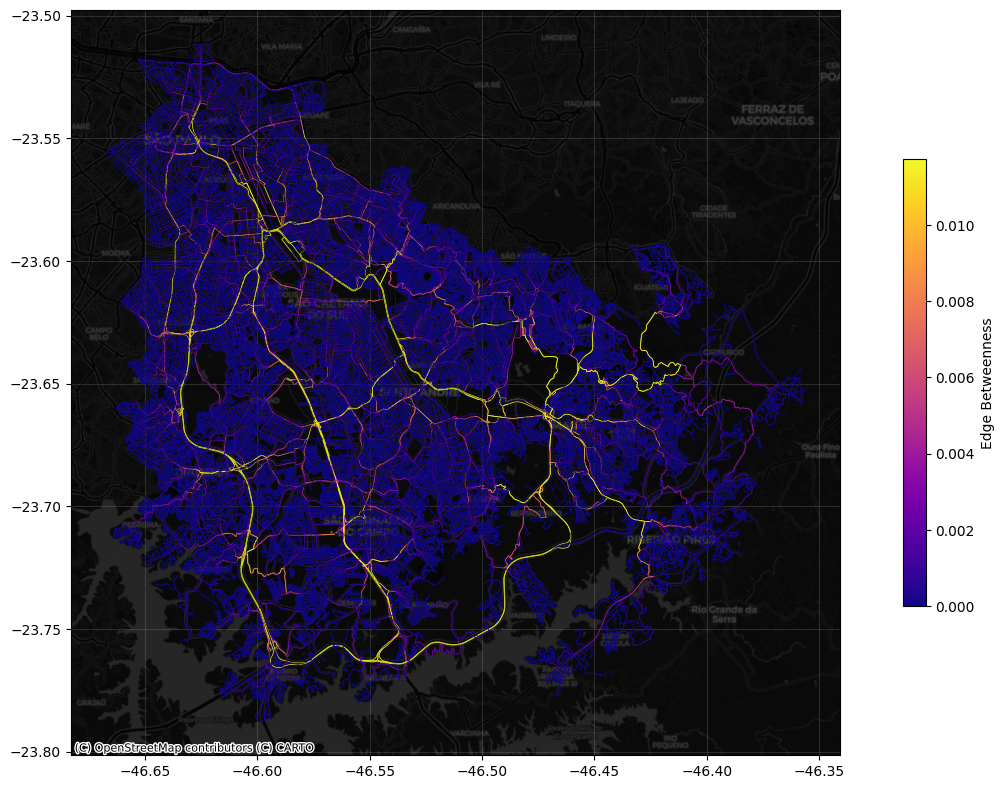

In [11]:
create_edge_map(edges_gdf, "e_ij", "Edge Betweenness")

## Edge Vulnerability ($v_{ij}$)

In [ ]:
v_ij_gdf = edges_gdf[edges_gdf["v_ij"] > 0].copy()
create_edge_map(v_ij_gdf, "v_ij", "Edge Vulnerability", log_scale=True, station_gdf=station_413)